<a href="https://colab.research.google.com/github/ghosucipto62-afk/Analytical-Project/blob/main/BTH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf

# Download Bitcoin data (BTC-USD) from Yahoo Finance
btc_data = yf.download('BTC-USD', start='2014-01-01', end='2023-01-01') # Adjust start/end dates as needed

# Display the first few rows of the data
print(btc_data.head())

/tmp/ipykernel_30796/1113002020.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_data = yf.download('BTC-USD', start='2014-01-01', end='2023-01-01') # Adjust start/end dates as needed
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker         BTC-USD     BTC-USD     BTC-USD     BTC-USD   BTC-USD
Date                                                                
2014-09-17  457.334015  468.174011  452.421997  465.864014  21056800
2014-09-18  424.440002  456.859985  413.104004  456.859985  34483200
2014-09-19  394.795990  427.834991  384.532013  424.102997  37919700
2014-09-20  408.903992  423.295990  389.882996  394.673004  36863600
2014-09-21  398.821014  412.425995  393.181000  408.084991  26580100


In [2]:
display(btc_data.describe())

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,3028.000000,3028.000000,3028.000000,3028.000000,3.028000e+03
mean,12862.178425,13182.567711,12495.418710,12858.370058,1.634383e+10
std,16185.351172,16604.605750,15710.663914,16190.316636,1.997501e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,675.556259,684.548492,663.220993,672.789017,1.006505e+08
50%,7106.541992,7287.041260,6894.411133,7097.275635,7.367460e+09
75%,16803.772949,17089.460938,16530.455566,16804.387207,2.792719e+10
max,67566.828125,68789.625000,66382.062500,67549.734375,3.509679e+11


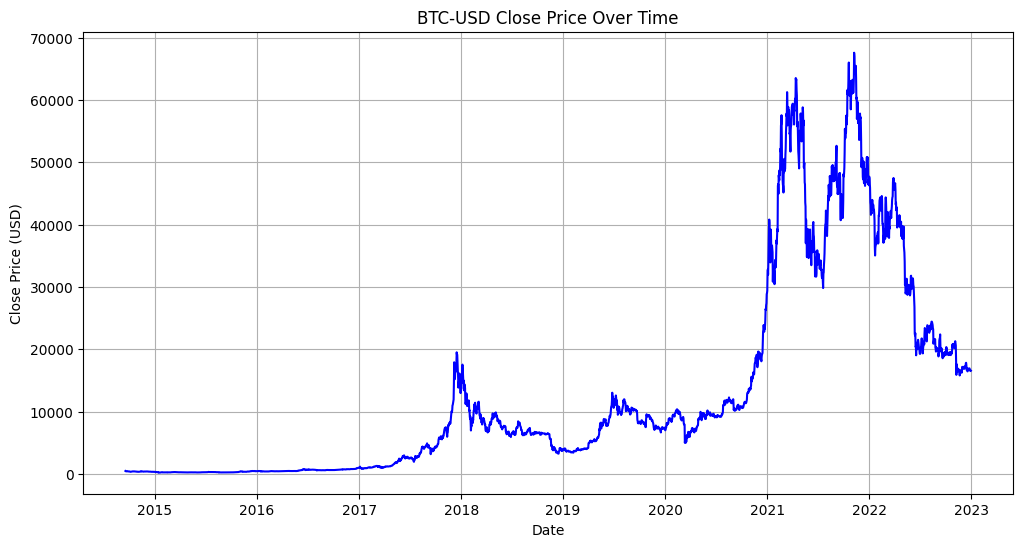

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(btc_data.index, btc_data['Close'], color='blue')
plt.title('BTC-USD Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True)
plt.show()

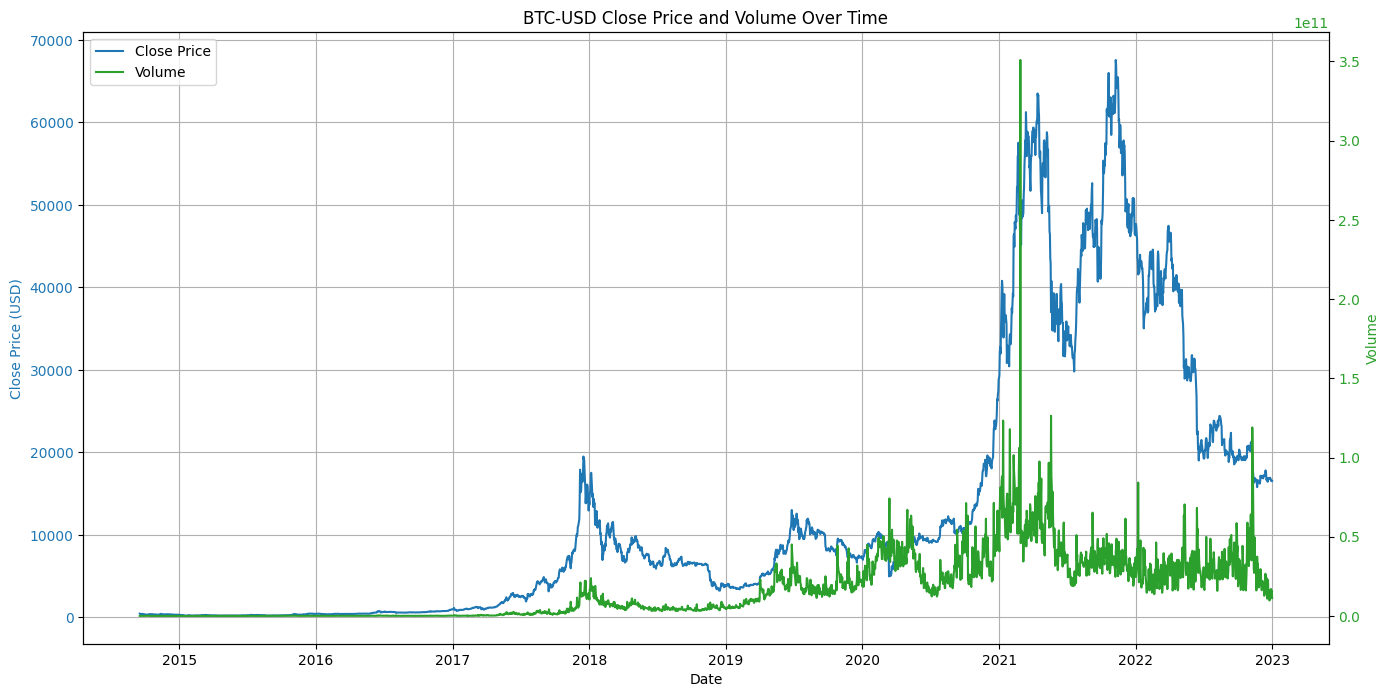

In [4]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Close Price on primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price (USD)', color=color)
ax1.plot(btc_data.index, btc_data['Close'], color=color, label='Close Price')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Create a secondary y-axis for Volume
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Volume', color=color)
ax2.plot(btc_data.index, btc_data['Volume'], color=color, label='Volume')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legends
fig.tight_layout()  # Adjust layout to prevent overlapping elements
plt.title('BTC-USD Close Price and Volume Over Time')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

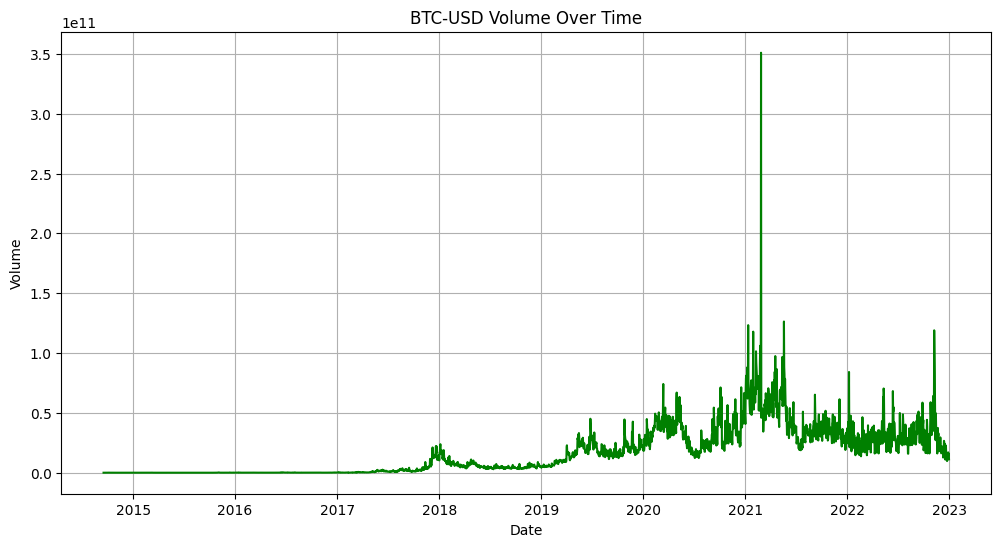

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(btc_data.index, btc_data['Volume'], color='green')
plt.title('BTC-USD Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

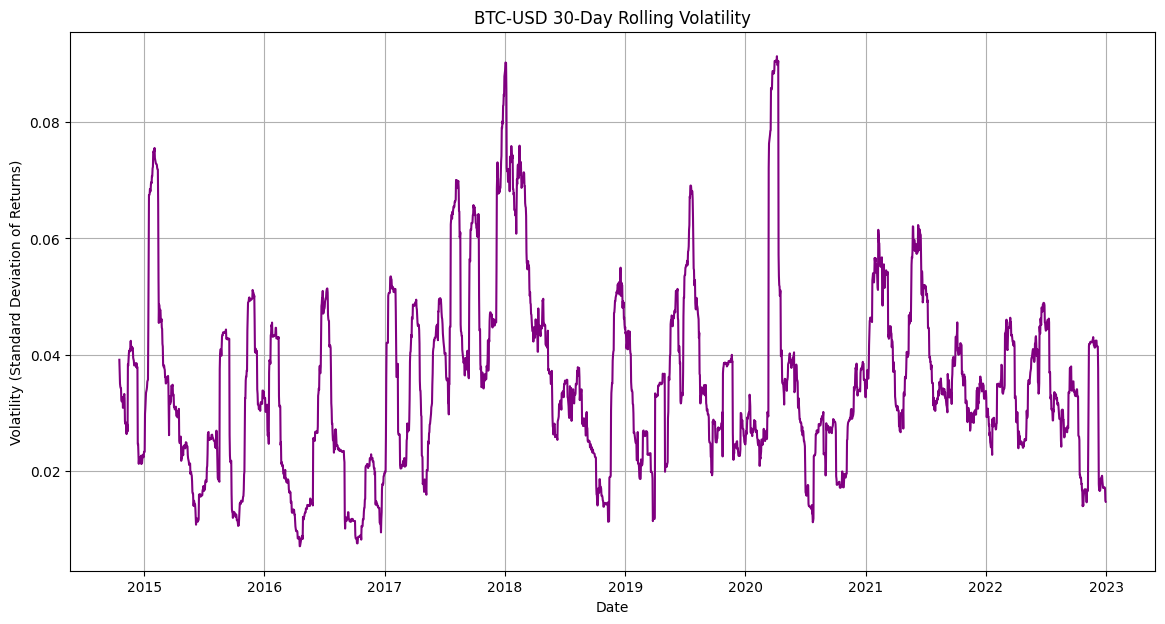

In [6]:
import matplotlib.pyplot as plt

# Calculate daily returns
bc_returns = btc_data['Close'].pct_change()

# Calculate rolling standard deviation (volatility) over a 30-day window
rolling_volatility = bc_returns.rolling(window=30).std()

plt.figure(figsize=(14, 7))
plt.plot(rolling_volatility.index, rolling_volatility, color='purple')
plt.title('BTC-USD 30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation of Returns)')
plt.grid(True)
plt.show()

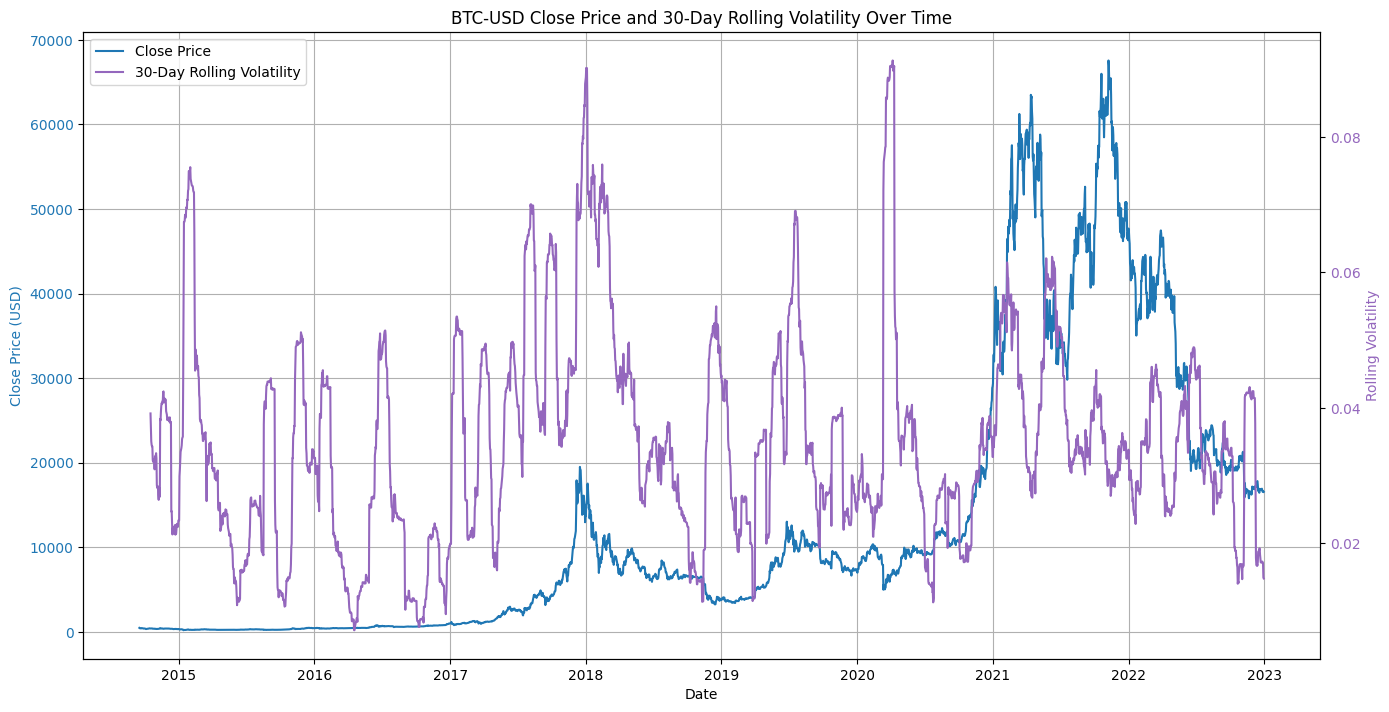

In [7]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Close Price on primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price (USD)', color=color)
ax1.plot(btc_data.index, btc_data['Close'], color=color, label='Close Price')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Create a secondary y-axis for Rolling Volatility
ax2 = ax1.twinx()
color = 'tab:purple'
ax2.set_ylabel('Rolling Volatility', color=color)
ax2.plot(rolling_volatility.index, rolling_volatility, color=color, label='30-Day Rolling Volatility')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legends
fig.tight_layout()  # Adjust layout to prevent overlapping elements
plt.title('BTC-USD Close Price and 30-Day Rolling Volatility Over Time')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

In [8]:
# Ensure both series are aligned by index and drop NaN values for correlation calculation
# The rolling_volatility has NaN values at the beginning, so we align and drop those.

aligned_data = btc_data['Close'].dropna().align(rolling_volatility.dropna(), join='inner')

# Calculate the correlation by converting single-column DataFrames to Series using .squeeze()
correlation = aligned_data[0].squeeze().corr(aligned_data[1].squeeze())

print(f"Correlation between Close Price and 30-Day Rolling Volatility: {correlation}")

Correlation between Close Price and 30-Day Rolling Volatility: 0.13354048777710045


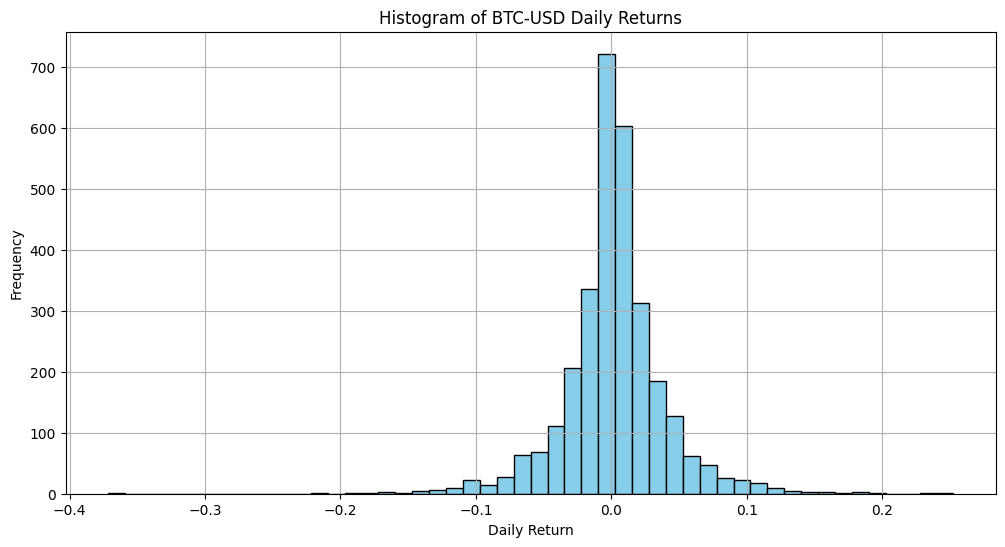

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(bc_returns.dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of BTC-USD Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [10]:
!pip install keras-tuner

In [11]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import pandas as pd # Import pandas for DataFrame operations

# --- 1. Data Preprocessing (with multiple features) ---

# Extract relevant features: Close, Volume, and Rolling Volatility
# Ensure correct column access for multi-indexed DataFrame if applicable
close_price = btc_data[('Close', 'BTC-USD')].copy()
volume = btc_data[('Volume', 'BTC-USD')].copy()

# rolling_volatility is already a DataFrame with column 'BTC-USD'
volatility = rolling_volatility[('BTC-USD')].copy()

# Combine features into a single DataFrame
# Aligning by index and dropping NaNs ensures all features correspond to the same dates
combined_data = pd.concat([close_price, volume, volatility], axis=1).dropna()
combined_data.columns = ['Close', 'Volume', 'Volatility'] # Rename columns for clarity

# Use all combined features for scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(combined_data)

# Define function to create sequences for LSTM/GRU
def create_sequences(data, time_step, n_features):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), :])  # Take all features for X
        y.append(data[i + time_step, 0])      # Predict only the 'Close' price (first feature)
    return np.array(X), np.array(y)

# Define the time step (number of previous days to consider for prediction)
time_step = 60 # Using 60 previous days to predict the next day
num_features = scaled_data.shape[1] # Number of features is now 3 (Close, Volume, Volatility)

X, y = create_sequences(scaled_data, time_step, num_features)

# Split data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

# Reshape input to be [samples, time_steps, features] for LSTM/GRU
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], num_features)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], num_features)

print(f"Shape of combined_data: {combined_data.shape}")
print(f"Number of features: {num_features}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of combined_data: (2998, 3)
Number of features: 3
Shape of X_train: (2350, 60, 3)
Shape of y_train: (2350,)
Shape of X_test: (588, 60, 3)
Shape of y_test: (588,)


In [12]:
# --- 2. Build and Tune the Hybrid LSTM+GRU Model using Keras Tuner ---

def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('lstm_units', min_value=50, max_value=200, step=50),
                   return_sequences=True,
                   input_shape=(time_step, num_features))) # Updated input_shape
    model.add(Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(GRU(units=hp.Int('gru_units', min_value=50, max_value=200, step=50),
                  return_sequences=False))
    model.add(Dropout(hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(units=hp.Int('dense_units', min_value=25, max_value=100, step=25)))
    model.add(Dense(units=1))

    model.compile(optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']),
                  loss='mean_squared_error')
    return model

# Initialize the Keras Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='btc_lstm_gru_tuning',
    overwrite=True
)

print("Searching for the best hyperparameters...")
# Use EarlyStopping to prevent overfitting during tuning
stop_early = EarlyStopping(monitor='val_loss', patience=5)

tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The best hyperparameters are: {best_hps}")

# Build the model with the optimal hyperparameters and train it
model = tuner.hypermodel.build(best_hps)

# Use EarlyStopping for final model training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the final model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

print("Model training complete with best hyperparameters.")

Trial 10 Complete [00h 01m 07s]
val_loss: 0.0018358187517151237

Best val_loss So Far: 0.0011182030430063605
Total elapsed time: 00h 17m 25s
The best hyperparameters are: <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x7f7e88f6cef0>
Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 17s 225ms/step - loss: 8.4850e-04 - val_loss: 0.0056
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 219ms/step - loss: 2.2731e-04 - val_loss: 0.0022
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - loss: 1.3388e-04 - val_loss: 0.0023
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - loss: 1.3823e-04 - val_loss: 0.0022
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - loss: 1.2602e-04 - val_loss: 0.0031
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - loss: 1.2086e-04 - val_loss: 0.0035
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - loss: 1.0757e-04 - val_loss: 0.0038
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 21s 223ms/step - loss: 1.2122e-04 - val_loss: 0.

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
Mean Absolute Error (MAE): 1694.65
Mean Absolute Percentage Error (MAPE): 5.17%


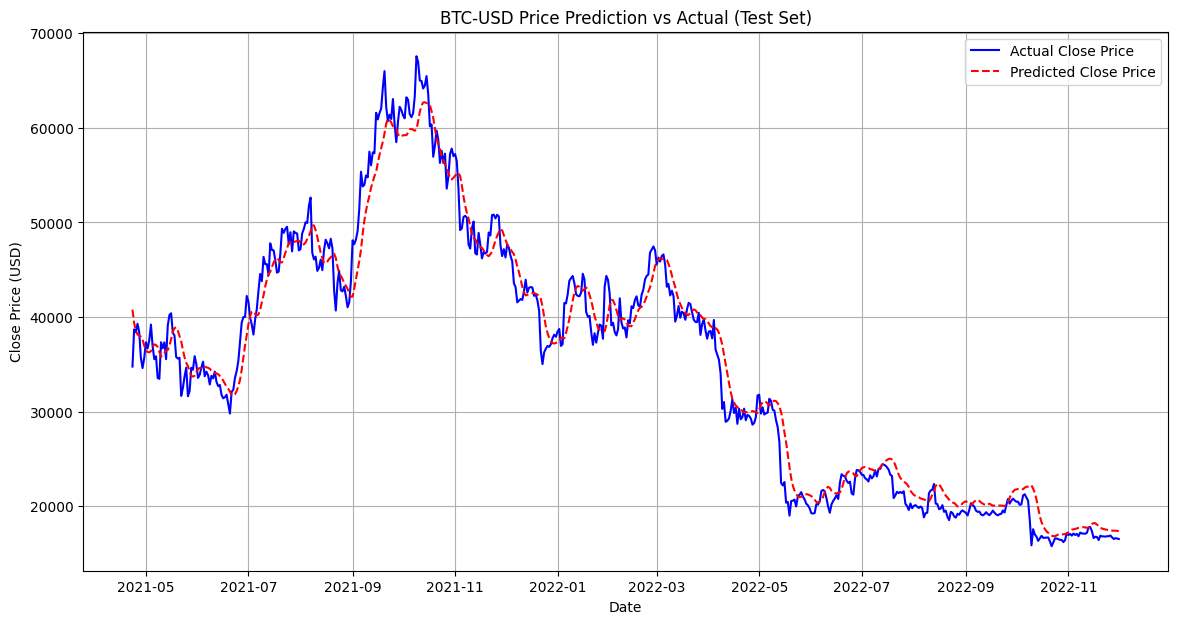

In [13]:
from sklearn.metrics import mean_absolute_error

# --- 3. Make Predictions and Evaluate the Model ---

# Make predictions on the test set
test_predict = model.predict(X_test)

# Inverse transform the predictions to original scale
# test_predict has shape (N, 1), but scaler was fitted on data with num_features columns (e.g., 3).
# We need to create a temporary array of shape (N, num_features) for inverse transformation.
temp_predict_reshaped = np.zeros((len(test_predict), num_features))
temp_predict_reshaped[:, 0] = test_predict.flatten() # Assuming Close price is the first feature (index 0)

test_predict_actual = scaler.inverse_transform(temp_predict_reshaped)[:, 0]


# Inverse transform y_test to original scale
# y_test has shape (N,), reshape to (N, 1) then prepare for num_features
temp_y_test_reshaped = np.zeros((len(y_test), num_features))
temp_y_test_reshaped[:, 0] = y_test.flatten() # Assuming Close price is the first feature (index 0)

y_test_inv_actual = scaler.inverse_transform(temp_y_test_reshaped)[:, 0]

# Calculate MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test_inv_actual, test_predict_actual)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_inv_actual, test_predict_actual)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# --- Visualize Predictions ---

# Create a DataFrame for easier plotting
# The original btc_data index ends at '2023-01-01'
# X_test starts after the training set, so we need to correctly align dates.

# Get the index for the test set predictions
# The original 'data' had 'time_step' fewer rows than btc_data for X, y creation.
# So, the original index for X, y starts at btc_data.index[time_step]
# The test set starts at btc_data.index[time_step + train_size]

test_dates = btc_data.index[time_step + train_size : time_step + train_size + len(y_test_inv_actual)]

plt.figure(figsize=(14, 7))
plt.plot(test_dates, y_test_inv_actual, label='Actual Close Price', color='blue')
plt.plot(test_dates, test_predict_actual, label='Predicted Close Price', color='red', linestyle='--')
plt.title('BTC-USD Price Prediction vs Actual (Test Set)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━

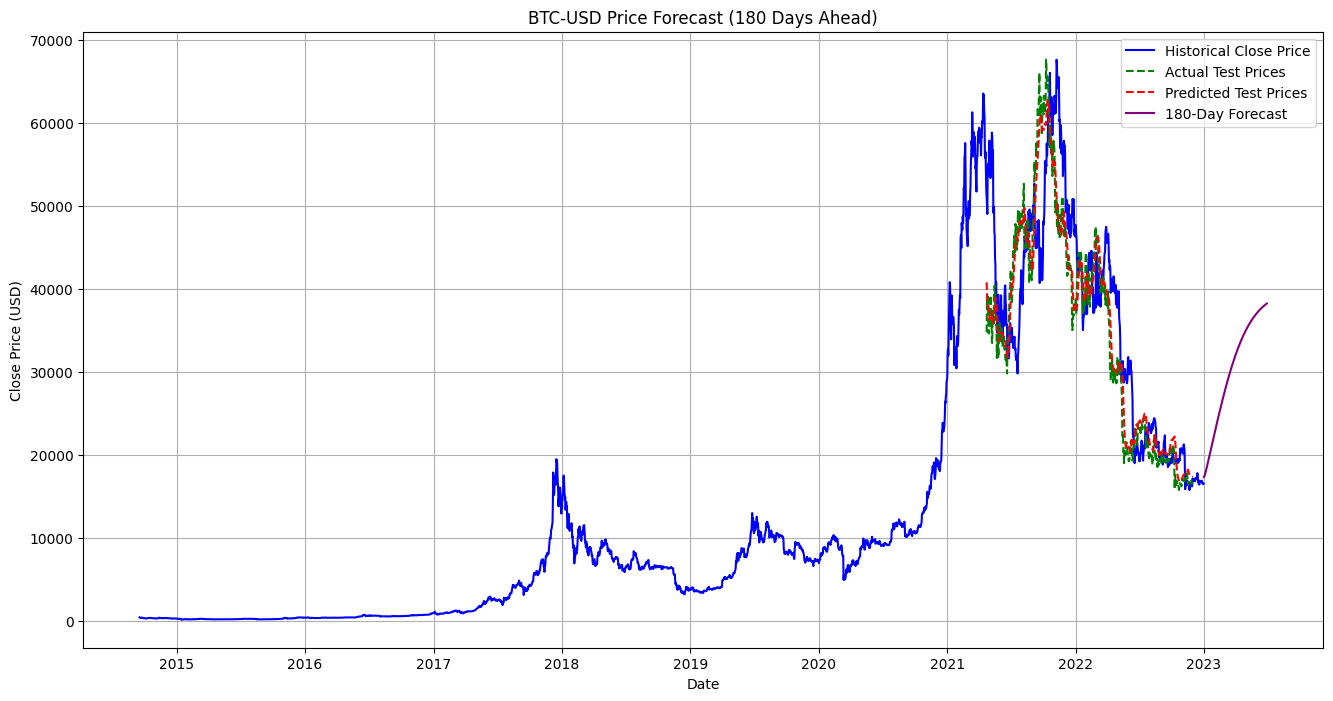

In [15]:
import pandas as pd

# --- 4. Forecast Future Prices ---

# Get the last 'time_step' days from the scaled data to start forecasting
last_time_step_data = scaled_data[-time_step:]

future_predictions = []
# Initialize current_input with the correct number of features
current_input = last_time_step_data.reshape(1, time_step, num_features)

num_forecast_days = 180 # Forecast for 180 days

for _ in range(num_forecast_days):
    # Predict the next day's 'Close' price (scaled)
    next_day_scaled_close_prediction = model.predict(current_input)[0, 0]
    future_predictions.append(next_day_scaled_close_prediction)

    # Prepare the new input for the next prediction step
    # The model only predicts 'Close' (the first feature). For the other features (Volume, Volatility),
    # we will carry forward their values from the last time step in the current input sequence.
    last_known_features_for_next_step = np.copy(current_input[0, -1, :])
    # Update the 'Close' price (index 0) with the new prediction
    last_known_features_for_next_step[0] = next_day_scaled_close_prediction

    # Remove the oldest time step and append the new feature vector
    # new_day_features needs to be reshaped to (1, 1, num_features) to be concatenated correctly
    current_input = np.concatenate(
        (current_input[:, 1:, :],
         last_known_features_for_next_step.reshape(1, 1, num_features)),
        axis=1
    )

# Inverse transform the future predictions to original scale
# Create a temporary array of shape (N, num_features) for inverse transformation,
# placing the single-feature predictions into the 'Close' price column.
temp_future_predict_reshaped = np.zeros((len(future_predictions), num_features))
temp_future_predict_reshaped[:, 0] = np.array(future_predictions).flatten()

future_predictions_inv = scaler.inverse_transform(temp_future_predict_reshaped)[:, 0]

# Generate future dates
last_historical_date = btc_data.index[-1]
future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=num_forecast_days)

# --- 5. Visualize Forecasted Prices ---

plt.figure(figsize=(16, 8))
plt.plot(btc_data.index, btc_data['Close'], label='Historical Close Price', color='blue')
plt.plot(test_dates, y_test_inv_actual, label='Actual Test Prices', color='green', linestyle='--') # Use y_test_inv_actual
plt.plot(test_dates, test_predict_actual, label='Predicted Test Prices', color='red', linestyle='--') # Use test_predict_actual
plt.plot(future_dates, future_predictions_inv, label='180-Day Forecast', color='purple', linestyle='-')

plt.title('BTC-USD Price Forecast (180 Days Ahead)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Close Price (USD)': future_predictions_inv.flatten()
})

display(forecast_df)

,Date,Predicted Close Price (USD)
0,2023-01-01,17345.488065
1,2023-01-02,17399.930160
2,2023-01-03,17506.520824
3,2023-01-04,17640.428936
4,2023-01-05,17789.937837
...,...,...
175,2023-06-25,38097.299028
176,2023-06-26,38130.826265
177,2023-06-27,38163.795182
178,2023-06-28,38196.185698


In [17]:
# Calculate the correlation between Close Price and Volume
# Accessing the specific Series from the multi-indexed DataFrame
correlation_close_volume = btc_data[('Close', 'BTC-USD')].corr(btc_data[('Volume', 'BTC-USD')])
print(f"Correlation between Close Price and Volume: {correlation_close_volume}")

Correlation between Close Price and Volume: 0.7151579715697342


## 12. GARCH Volatility Modeling

GARCH (Generalized Autoregressive Conditional Heteroskedasticity) models are used to model the conditional variance of a time series, capturing phenomena like volatility clustering (periods of high volatility followed by high volatility, and vice versa).

We'll fit a GARCH(1,1) model to the daily returns (`bc_returns`) to forecast future volatility. GARCH(1,1) is a common choice, meaning the conditional variance is a linear function of the previous period's squared error and the previous period's conditional variance.

In [24]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.5 MB/s eta 0:00:00


In [25]:
from arch import arch_model

# Ensure returns are cleaned (no NaNs) and in the correct format for GARCH
# GARCH models expect a Series of returns, typically centered around zero.
returns_for_garch = bc_returns.dropna() * 100 # Convert to percentage for better GARCH scaling

# Fit a GARCH(1,1) model
# mean='zero' is common for returns, vol='Garch' for GARCH(p,q), p=1, q=1
garch_model = arch_model(returns_for_garch, mean='Zero', vol='Garch', p=1, q=1, dist='StudentsT')
garch_res = garch_model.fit(disp='off') # disp='off' to suppress verbose output

print(garch_res.summary())

# Forecast future volatility (conditional standard deviation)
# We want to forecast for the same number of days as our price forecast (num_forecast_days)
garch_forecast = garch_res.forecast(horizon=num_forecast_days, start=returns_for_garch.index[-1], reindex=False)

# Extract the forecasted conditional standard deviation
# The forecast is for percentage returns, so divide by 100 to get decimal volatility
forecasted_volatility = np.sqrt(garch_forecast.variance.iloc[-1].values) / 100

print(f"\nFirst 5 forecasted daily volatilities (standard deviations):\n{forecasted_volatility[:5]}")
print(f"Last 5 forecasted daily volatilities (standard deviations):\n{forecasted_volatility[-5:]}")

                          Zero Mean - GARCH Model Results                           
Dep. Variable:                      BTC-USD   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -7730.80
Distribution:      Standardized Student's t   AIC:                           15469.6
Method:                  Maximum Likelihood   BIC:                           15493.7
                                              No. Observations:                 3027
Date:                      Fri, Mar 13 2026   Df Residuals:                     3027
Time:                              14:53:08   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega  

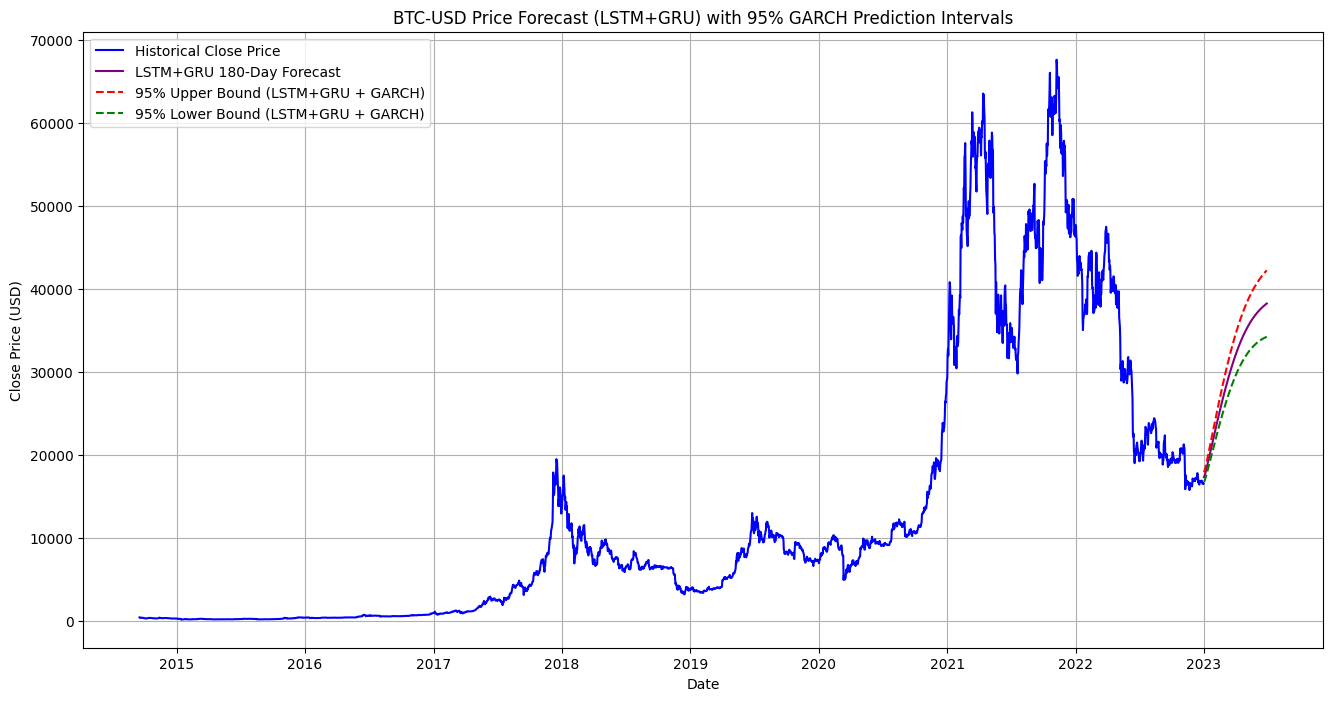

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'future_predictions_inv' holds the mean price forecast from the LSTM+GRU model
# and 'forecasted_volatility' holds the daily standard deviations from GARCH

# Calculate prediction intervals (e.g., 95% confidence interval)
# Using 1.96 standard deviations for a 95% confidence interval (assuming approximate normality for simplicity)
confidence_level_z = 1.96

# Calculate the price change corresponding to the volatility
# The forecasted_volatility is the standard deviation of percentage returns.
# To get the standard deviation of the price, we multiply this by the forecasted price itself.

upper_bound_lstm_gru = future_predictions_inv * (1 + confidence_level_z * forecasted_volatility)
lower_bound_lstm_gru = future_predictions_inv * (1 - confidence_level_z * forecasted_volatility)

plt.figure(figsize=(16, 8))
plt.plot(btc_data.index, btc_data['Close'], label='Historical Close Price', color='blue')
plt.plot(future_dates, future_predictions_inv, label='LSTM+GRU 180-Day Forecast', color='purple', linestyle='-')
plt.plot(future_dates, upper_bound_lstm_gru, label='95% Upper Bound (LSTM+GRU + GARCH)', color='red', linestyle='--')
plt.plot(future_dates, lower_bound_lstm_gru, label='95% Lower Bound (LSTM+GRU + GARCH)', color='green', linestyle='--')

plt.title('BTC-USD Price Forecast (LSTM+GRU) with 95% GARCH Prediction Intervals')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
forecast_with_intervals_df = pd.DataFrame({
    'Date': future_dates,
    'LSTM+GRU Forecast (USD)': future_predictions_inv.flatten(),
    '95% Lower Bound (USD)': lower_bound_lstm_gru.flatten(),
    '95% Upper Bound (USD)': upper_bound_lstm_gru.flatten()
})

display(forecast_with_intervals_df)

# Save the DataFrame to an Excel file
forecast_with_intervals_df.to_excel('ForecastBTC.xlsx', index=False)
print("Forecast data saved to ForecastBTC.xlsx")

,Date,LSTM+GRU Forecast (USD),95% Lower Bound (USD),95% Upper Bound (USD)
0,2023-01-01,17345.488065,16764.757534,17926.218596
1,2023-01-02,17399.930160,16803.303370,17996.556949
2,2023-01-03,17506.520824,16892.405801,18120.635847
3,2023-01-04,17640.428936,17007.984513,18272.873359
4,2023-01-05,17789.937837,17138.675812,18441.199862
...,...,...,...,...
175,2023-06-25,38097.299028,34154.035776,42040.562280
176,2023-06-26,38130.826265,34174.009114,42087.643415
177,2023-06-27,38163.795182,34193.490138,42134.100226
178,2023-06-28,38196.185698,34212.461175,42179.910221


Forecast data saved to ForecastBTC.xlsx
